In [1]:

# Analysis Plan:
# 1. Define the Dirichlet character χ₄ and compute its coefficients a_n
# 2. Generate partial sum data D(t; N=10⁵) for L(χ₄) over t in [1000, 10000]
# 3. Identify the location t* of the highest peak in |D(t)|
# 4. At t*, partition terms by ω(n) (number of distinct prime factors)
# 5. Compute vector sum S_k for each class k from 1 to 5
# 6. Calculate cancellation metric M = |Σ_k S_k| / √Σ|S_k|²
# 7. Compare to known values: ζ (0.5-0.7), L_DH (~0.2), f_rand (~1.9)

import numpy as np
import pandas as pd
from scipy.stats import chi2
import matplotlib.pyplot as plt
from numba import jit
import json
from datetime import datetime

print("Starting analysis: Vector interference pattern at L(χ₄) peak")
print("="*70)


Starting analysis: Vector interference pattern at L(χ₄) peak


In [2]:

# Step 1: Define the Dirichlet character χ₄
# χ₄(n) = 0 if n is even, χ₄(n) = 1 if n ≡ 1 (mod 4), χ₄(n) = -1 if n ≡ 3 (mod 4)

def chi4(n):
 """Dirichlet character χ₄"""
 if n % 2 == 0:
 return 0
 elif n % 4 == 1:
 return 1
 else: # n % 4 == 3
 return -1

# Test the character
test_n = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
chi4_values = [chi4(n) for n in test_n]
print("χ₄ values for n = 1-10:")
for n, val in zip(test_n, chi4_values):
 print(f" χ₄({n}) = {val}")

# Verify it's multiplicative
print("\nVerifying multiplicativity: χ₄(3)·χ₄(5) = χ₄(15)")
print(f" χ₄(3) = {chi4(3)}, χ₄(5) = {chi4(5)}, χ₄(3)·χ₄(5) = {chi4(3)*chi4(5)}")
print(f" χ₄(15) = {chi4(15)}")
print(f" Multiplicative: {chi4(3)*chi4(5) == chi4(15)}")


χ₄ values for n = 1-10:
 χ₄(1) = 1
 χ₄(2) = 0
 χ₄(3) = -1
 χ₄(4) = 0
 χ₄(5) = 1
 χ₄(6) = 0
 χ₄(7) = -1
 χ₄(8) = 0
 χ₄(9) = 1
 χ₄(10) = 0

Verifying multiplicativity: χ₄(3)·χ₄(5) = χ₄(15)
 χ₄(3) = -1, χ₄(5) = 1, χ₄(3)·χ₄(5) = -1
 χ₄(15) = -1
 Multiplicative: True


In [3]:

# Step 2: Compute number of distinct prime factors ω(n) for n ≤ 10⁵
# We'll precompute this using a sieve-like approach

def compute_omega(max_n):
 """Compute ω(n) = number of distinct prime factors for n ≤ max_n"""
 omega = np.zeros(max_n + 1, dtype=np.int32)
 
 for p in range(2, max_n + 1):
 if omega[p] == 0: # p is prime
 # Mark all multiples of p
 for multiple in range(p, max_n + 1, p):
 omega[multiple] += 1
 
 return omega

N_max = 100000
print(f"Computing ω(n) for n ≤ {N_max}...")
omega = compute_omega(N_max)
print(f"Done. ω(1) = {omega[1]}, ω(2) = {omega[2]}, ω(6) = {omega[6]}, ω(30) = {omega[30]}")

# Check distribution
print("\nDistribution of ω(n) values:")
for k in range(0, 7):
 count = np.sum(omega == k)
 print(f" ω(n) = {k}: {count} terms ({100*count/N_max:.2f}%)")


Computing ω(n) for n ≤ 100000...


Done. ω(1) = 0, ω(2) = 1, ω(6) = 2, ω(30) = 3

Distribution of ω(n) values:
 ω(n) = 0: 2 terms (0.00%)
 ω(n) = 1: 9700 terms (9.70%)
 ω(n) = 2: 33759 terms (33.76%)
 ω(n) = 3: 38844 terms (38.84%)
 ω(n) = 4: 15855 terms (15.86%)
 ω(n) = 5: 1816 terms (1.82%)
 ω(n) = 6: 25 terms (0.03%)


In [4]:

# Step 3: Generate partial sum data D(t; N=10⁵) for L(χ₄) over t in [1000, 10000]
# D(t; N) = Σ_{n≤N} χ₄(n) · n^(-1/2 - it)
# We'll use Kahan summation for numerical precision

@jit(nopython=True)
def kahan_sum_complex(values):
 """Kahan compensated summation for complex arrays"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def compute_partial_sum_lchi4(t, N):
 """Compute D(t; N) for L(χ₄) at a single t value"""
 n_values = np.arange(1, N + 1)
 chi4_values = np.array([chi4(n) for n in n_values], dtype=np.float64)
 
 # Compute n^(-1/2 - it) = n^(-1/2) * exp(-it * log(n))
 n_sqrt = n_values ** (-0.5)
 log_n = np.log(n_values)
 exp_terms = np.exp(-1j * t * log_n)
 
 # Combine terms
 terms = chi4_values * n_sqrt * exp_terms
 
 # Use Kahan summation
 D_t = kahan_sum_complex(terms)
 
 return D_t

# Test with a single t value
t_test = 1000.0
D_test = compute_partial_sum_lchi4(t_test, N_max)
print(f"Test: D(t={t_test}; N={N_max}) = {D_test}")
print(f" |D| = {np.abs(D_test):.6f}")


Test: D(t=1000.0; N=100000) = (-0.015706579531080338-2.8576342122699927j)
 |D| = 2.857677


In [5]:

# Now compute D(t) for a range of t values
# We'll use a spacing that captures the peaks
# From the dataset description, the peaks can be quite sharp

t_min = 1000
t_max = 10000
dt = 0.5 # Use a fine grid to capture sharp peaks

t_values = np.arange(t_min, t_max + dt, dt)
print(f"Computing D(t; N={N_max}) for {len(t_values)} t values in [{t_min}, {t_max}]...")
print(f"This will take a few minutes...")

# Compute D(t) for all t values
D_values = np.array([compute_partial_sum_lchi4(t, N_max) for t in t_values])
D_magnitude = np.abs(D_values)

print(f"Done. Computed {len(D_values)} values.")
print(f"Range of |D(t)|: [{D_magnitude.min():.4f}, {D_magnitude.max():.4f}]")


Computing D(t; N=100000) for 18001 t values in [1000, 10000]...
This will take a few minutes...


Done. Computed 18001 values.
Range of |D(t)|: [0.0003, 11.7653]


In [6]:

# Step 4: Identify the location t* of the highest peak in |D(t)|
idx_max = np.argmax(D_magnitude)
t_star = t_values[idx_max]
D_star = D_values[idx_max]
D_star_mag = D_magnitude[idx_max]

print(f"Highest peak location:")
print(f" t* = {t_star:.2f}")
print(f" |D(t*)| = {D_star_mag:.6f}")
print(f" D(t*) = {D_star.real:.6f} + {D_star.imag:.6f}i")

# Find top 5 peaks for context
top_5_idx = np.argsort(D_magnitude)[-5:][::-1]
print(f"\nTop 5 peaks:")
for i, idx in enumerate(top_5_idx, 1):
 print(f" {i}. t = {t_values[idx]:.2f}, |D| = {D_magnitude[idx]:.6f}")


Highest peak location:
 t* = 9908.50
 |D(t*)| = 11.765265
 D(t*) = 11.325982 + -3.184903i

Top 5 peaks:
 1. t = 9908.50, |D| = 11.765265
 2. t = 8713.50, |D| = 11.357201
 3. t = 7312.00, |D| = 10.890698
 4. t = 7964.00, |D| = 10.845520
 5. t = 6562.50, |D| = 10.725696


In [7]:

# Step 5: At t*, partition terms by ω(n) and compute vector sum S_k for each class
# S_k = Σ_{ω(n)=k} χ₄(n) · n^(-1/2 - it*)

print(f"\nComputing vector sums S_k at t* = {t_star:.2f}:")
print("="*70)

# Precompute χ₄ values and terms for all n
n_values = np.arange(1, N_max + 1)
chi4_values = np.array([chi4(n) for n in n_values], dtype=np.float64)
n_sqrt = n_values ** (-0.5)
log_n = np.log(n_values)
exp_terms = np.exp(-1j * t_star * log_n)
all_terms = chi4_values * n_sqrt * exp_terms

# Compute S_k for k = 0 to max(ω)
max_omega = omega.max()
S_k = {}

for k in range(0, max_omega + 1):
 mask = (omega[1:] == k) # omega is indexed from 0, but we start from n=1
 terms_k = all_terms[mask]
 S_k[k] = kahan_sum_complex(terms_k)
 
 print(f"k = {k} (ω(n) = {k}):")
 print(f" Number of terms: {np.sum(mask)}")
 print(f" S_{k} = {S_k[k].real:.6f} + {S_k[k].imag:.6f}i")
 print(f" |S_{k}| = {np.abs(S_k[k]):.6f}")
 print()



Computing vector sums S_k at t* = 9908.50:
k = 0 (ω(n) = 0):
 Number of terms: 1
 S_0 = 1.000000 + 0.000000i
 |S_0| = 1.000000

k = 1 (ω(n) = 1):
 Number of terms: 9700
 S_1 = 3.137157 + -0.364993i
 |S_1| = 3.158318

k = 2 (ω(n) = 2):
 Number of terms: 33759
 S_2 = 2.928040 + -0.652271i
 |S_2| = 2.999812

k = 3 (ω(n) = 3):
 Number of terms: 38844
 S_3 = 2.493759 + -0.979611i
 |S_3| = 2.679267

k = 4 (ω(n) = 4):
 Number of terms: 15855
 S_4 = 1.649682 + -1.106565i
 |S_4| = 1.986438

k = 5 (ω(n) = 5):
 Number of terms: 1816
 S_5 = 0.117344 + -0.081463i
 |S_5| = 0.142849

k = 6 (ω(n) = 6):
 Number of terms: 25
 S_6 = 0.000000 + 0.000000i
 |S_6| = 0.000000



In [8]:

# Step 6: Calculate the cancellation metric M = |Σ_k S_k| / √Σ|S_k|²
# According to the objective, we should use k from 1 to 5

# Total sum
S_total = sum(S_k[k] for k in range(1, 6))
print(f"Total sum S_total = Σ_(k=1 to 5) S_k:")
print(f" S_total = {S_total.real:.6f} + {S_total.imag:.6f}i")
print(f" |S_total| = {np.abs(S_total):.6f}")
print()

# Sum of squared magnitudes
sum_squared_magnitudes = sum(np.abs(S_k[k])**2 for k in range(1, 6))
print(f"Sum of squared magnitudes Σ|S_k|²:")
print(f" Σ|S_k|² = {sum_squared_magnitudes:.6f}")
print(f" √Σ|S_k|² = {np.sqrt(sum_squared_magnitudes):.6f}")
print()

# Cancellation metric M
M = np.abs(S_total) / np.sqrt(sum_squared_magnitudes)
print(f"Cancellation metric M:")
print(f" M = |S_total| / √Σ|S_k|²")
print(f" M = {M:.6f}")
print()

print("="*70)
print("COMPARISON TO KNOWN VALUES:")
print("="*70)
print(f" L(χ₄) at peak (this analysis): M = {M:.3f}")
print(f" ζ peaks (from r35): M ≈ 0.5-0.7")
print(f" L_DH resonances: M ≈ 0.2")
print(f" f_rand: M ≈ 1.9")
print()

if 0.5 <= M <= 0.7:
 print(f"✓ M = {M:.3f} falls within the ζ peak range [0.5, 0.7]")
elif M < 0.5:
 print(f"✗ M = {M:.3f} is LESS than the ζ peak range [0.5, 0.7]")
elif M > 0.7:
 print(f"✗ M = {M:.3f} is GREATER than the ζ peak range [0.5, 0.7]")


Total sum S_total = Σ_(k=1 to 5) S_k:
 S_total = 10.325982 + -3.184903i
 |S_total| = 10.805994

Sum of squared magnitudes Σ|S_k|²:
 Σ|S_k|² = 30.118660
 √Σ|S_k|² = 5.488047

Cancellation metric M:
 M = |S_total| / √Σ|S_k|²
 M = 1.969005

COMPARISON TO KNOWN VALUES:
 L(χ₄) at peak (this analysis): M = 1.969
 ζ peaks (from r35): M ≈ 0.5-0.7
 L_DH resonances: M ≈ 0.2
 f_rand: M ≈ 1.9

✗ M = 1.969 is GREATER than the ζ peak range [0.5, 0.7]


In [9]:

# This is a very surprising result! M ≈ 1.97 is very close to f_rand (≈1.9)
# This suggests CONSTRUCTIVE interference, not destructive interference like ζ
# Let's verify our calculation is correct

print("VERIFICATION OF CALCULATION:")
print("="*70)

# Verify that S_total matches D(t*)
print(f"\n1. Check that Σ_k S_k matches D(t*):")
print(f" Σ_(k=0 to 6) S_k = {sum(S_k[k] for k in range(0, 7))}")
print(f" D(t*) = {D_star}")
print(f" Match: {np.allclose(sum(S_k[k] for k in range(0, 7)), D_star)}")

# Note that k=0 is just n=1, and k=6 has zero contribution
print(f"\n2. Contribution from k=0 (n=1 only):")
print(f" S_0 = {S_k[0]}")
print(f" This is just χ₄(1) · 1^(-1/2 - it*) = 1")

print(f"\n3. Recalculate M with k=1 to 5:")
S_1_to_5 = sum(S_k[k] for k in range(1, 6))
sum_sq_1_to_5 = sum(np.abs(S_k[k])**2 for k in range(1, 6))
M_1_to_5 = np.abs(S_1_to_5) / np.sqrt(sum_sq_1_to_5)
print(f" S_total (k=1-5) = {S_1_to_5}")
print(f" |S_total| = {np.abs(S_1_to_5):.6f}")
print(f" √Σ|S_k|² = {np.sqrt(sum_sq_1_to_5):.6f}")
print(f" M = {M_1_to_5:.6f}")

print(f"\n4. For comparison, calculate M if we use k=0 to 5:")
S_0_to_5 = sum(S_k[k] for k in range(0, 6))
sum_sq_0_to_5 = sum(np.abs(S_k[k])**2 for k in range(0, 6))
M_0_to_5 = np.abs(S_0_to_5) / np.sqrt(sum_sq_0_to_5)
print(f" M (k=0-5) = {M_0_to_5:.6f}")


VERIFICATION OF CALCULATION:

1. Check that Σ_k S_k matches D(t*):
 Σ_(k=0 to 6) S_k = (11.325981585652219-3.1849029748823026j)
 D(t*) = (11.325981585652217-3.1849029748823026j)
 Match: True

2. Contribution from k=0 (n=1 only):
 S_0 = (1+0j)
 This is just χ₄(1) · 1^(-1/2 - it*) = 1

3. Recalculate M with k=1 to 5:
 S_total (k=1-5) = (10.325981585652219-3.1849029748823026j)
 |S_total| = 10.805994
 √Σ|S_k|² = 5.488047
 M = 1.969005

4. For comparison, calculate M if we use k=0 to 5:
 M (k=0-5) = 2.109071


In [10]:

# Let's verify this surprising result by checking other peaks in L(χ₄)
# We'll compute M for the top 5 peaks

print("COMPUTING M FOR TOP 5 PEAKS:")
print("="*70)

M_values = []
peak_data = []

for rank, idx in enumerate(top_5_idx, 1):
 t_peak = t_values[idx]
 D_peak = D_values[idx]
 D_peak_mag = D_magnitude[idx]
 
 # Compute terms at this t
 exp_terms_peak = np.exp(-1j * t_peak * log_n)
 all_terms_peak = chi4_values * n_sqrt * exp_terms_peak
 
 # Compute S_k for this peak
 S_k_peak = {}
 for k in range(0, 6):
 mask = (omega[1:] == k)
 terms_k = all_terms_peak[mask]
 S_k_peak[k] = kahan_sum_complex(terms_k)
 
 # Compute M
 S_total_peak = sum(S_k_peak[k] for k in range(1, 6))
 sum_sq_peak = sum(np.abs(S_k_peak[k])**2 for k in range(1, 6))
 M_peak = np.abs(S_total_peak) / np.sqrt(sum_sq_peak)
 
 M_values.append(M_peak)
 peak_data.append({
 'rank': rank,
 't': t_peak,
 '|D(t)|': D_peak_mag,
 'M': M_peak
 })
 
 print(f"Peak #{rank}: t = {t_peak:.2f}, |D| = {D_peak_mag:.4f}, M = {M_peak:.4f}")

print()
print(f"Mean M across top 5 peaks: {np.mean(M_values):.4f} ± {np.std(M_values):.4f}")
print(f"Range: [{np.min(M_values):.4f}, {np.max(M_values):.4f}]")


COMPUTING M FOR TOP 5 PEAKS:
Peak #1: t = 9908.50, |D| = 11.7653, M = 1.9690
Peak #2: t = 8713.50, |D| = 11.3572, M = 1.8964
Peak #3: t = 7312.00, |D| = 10.8907, M = 1.8404
Peak #4: t = 7964.00, |D| = 10.8455, M = 1.7681
Peak #5: t = 6562.50, |D| = 10.7257, M = 1.8932

Mean M across top 5 peaks: 1.8734 ± 0.0667
Range: [1.7681, 1.9690]


In [11]:

# This is a striking and consistent pattern! All top 5 peaks show M ≈ 1.77-1.97
# This is much closer to f_rand (M ≈ 1.9) than to ζ (M ≈ 0.5-0.7)
# This suggests L(χ₄) peaks arise from CONSTRUCTIVE interference, not destructive

# Let's also check the behavior of the S_k vectors - are they aligned?
print("VECTOR ANALYSIS AT HIGHEST PEAK (t* = 9908.50):")
print("="*70)

print("\nVector components S_k (k=1 to 5):")
print(f"{'k':<5} {'|S_k|':<12} {'Re(S_k)':<15} {'Im(S_k)':<15} {'Phase (rad)':<15} {'Phase (deg)':<12}")
print("-"*80)

phases = []
for k in range(1, 6):
 S = S_k[k]
 mag = np.abs(S)
 phase = np.angle(S)
 phases.append(phase)
 print(f"{k:<5} {mag:<12.6f} {S.real:<15.6f} {S.imag:<15.6f} {phase:<15.6f} {np.degrees(phase):<12.2f}")

print(f"\nPhase statistics:")
print(f" Mean phase: {np.mean(phases):.4f} rad ({np.degrees(np.mean(phases)):.2f}°)")
print(f" Std dev: {np.std(phases):.4f} rad ({np.degrees(np.std(phases)):.2f}°)")
print(f" Range: [{np.min(phases):.4f}, {np.max(phases):.4f}] rad")
print(f" [{np.degrees(np.min(phases)):.2f}°, {np.degrees(np.max(phases)):.2f}°]")

# Compute the resultant length (measure of phase alignment)
# If phases are perfectly aligned, R = 1; if random, R ≈ 0
phase_vectors = np.array([np.exp(1j * phase) for phase in phases])
R = np.abs(np.mean(phase_vectors))
print(f"\nResultant length R = {R:.4f}")
print(f" (R = 1: perfect alignment, R ≈ 0: random phases)")


VECTOR ANALYSIS AT HIGHEST PEAK (t* = 9908.50):

Vector components S_k (k=1 to 5):
k |S_k| Re(S_k) Im(S_k) Phase (rad) Phase (deg) 
--------------------------------------------------------------------------------
1 3.158318 3.137157 -0.364993 -0.115824 -6.64 
2 2.999812 2.928040 -0.652271 -0.219188 -12.56 
3 2.679267 2.493759 -0.979611 -0.374306 -21.45 
4 1.986438 1.649682 -1.106565 -0.590841 -33.85 
5 0.142849 0.117344 -0.081463 -0.606841 -34.77 

Phase statistics:
 Mean phase: -0.3814 rad (-21.85°)
 Std dev: 0.1957 rad (11.22°)
 Range: [-0.6068, -0.1158] rad
 [-34.77°, -6.64°]

Resultant length R = 0.9809
 (R = 1: perfect alignment, R ≈ 0: random phases)


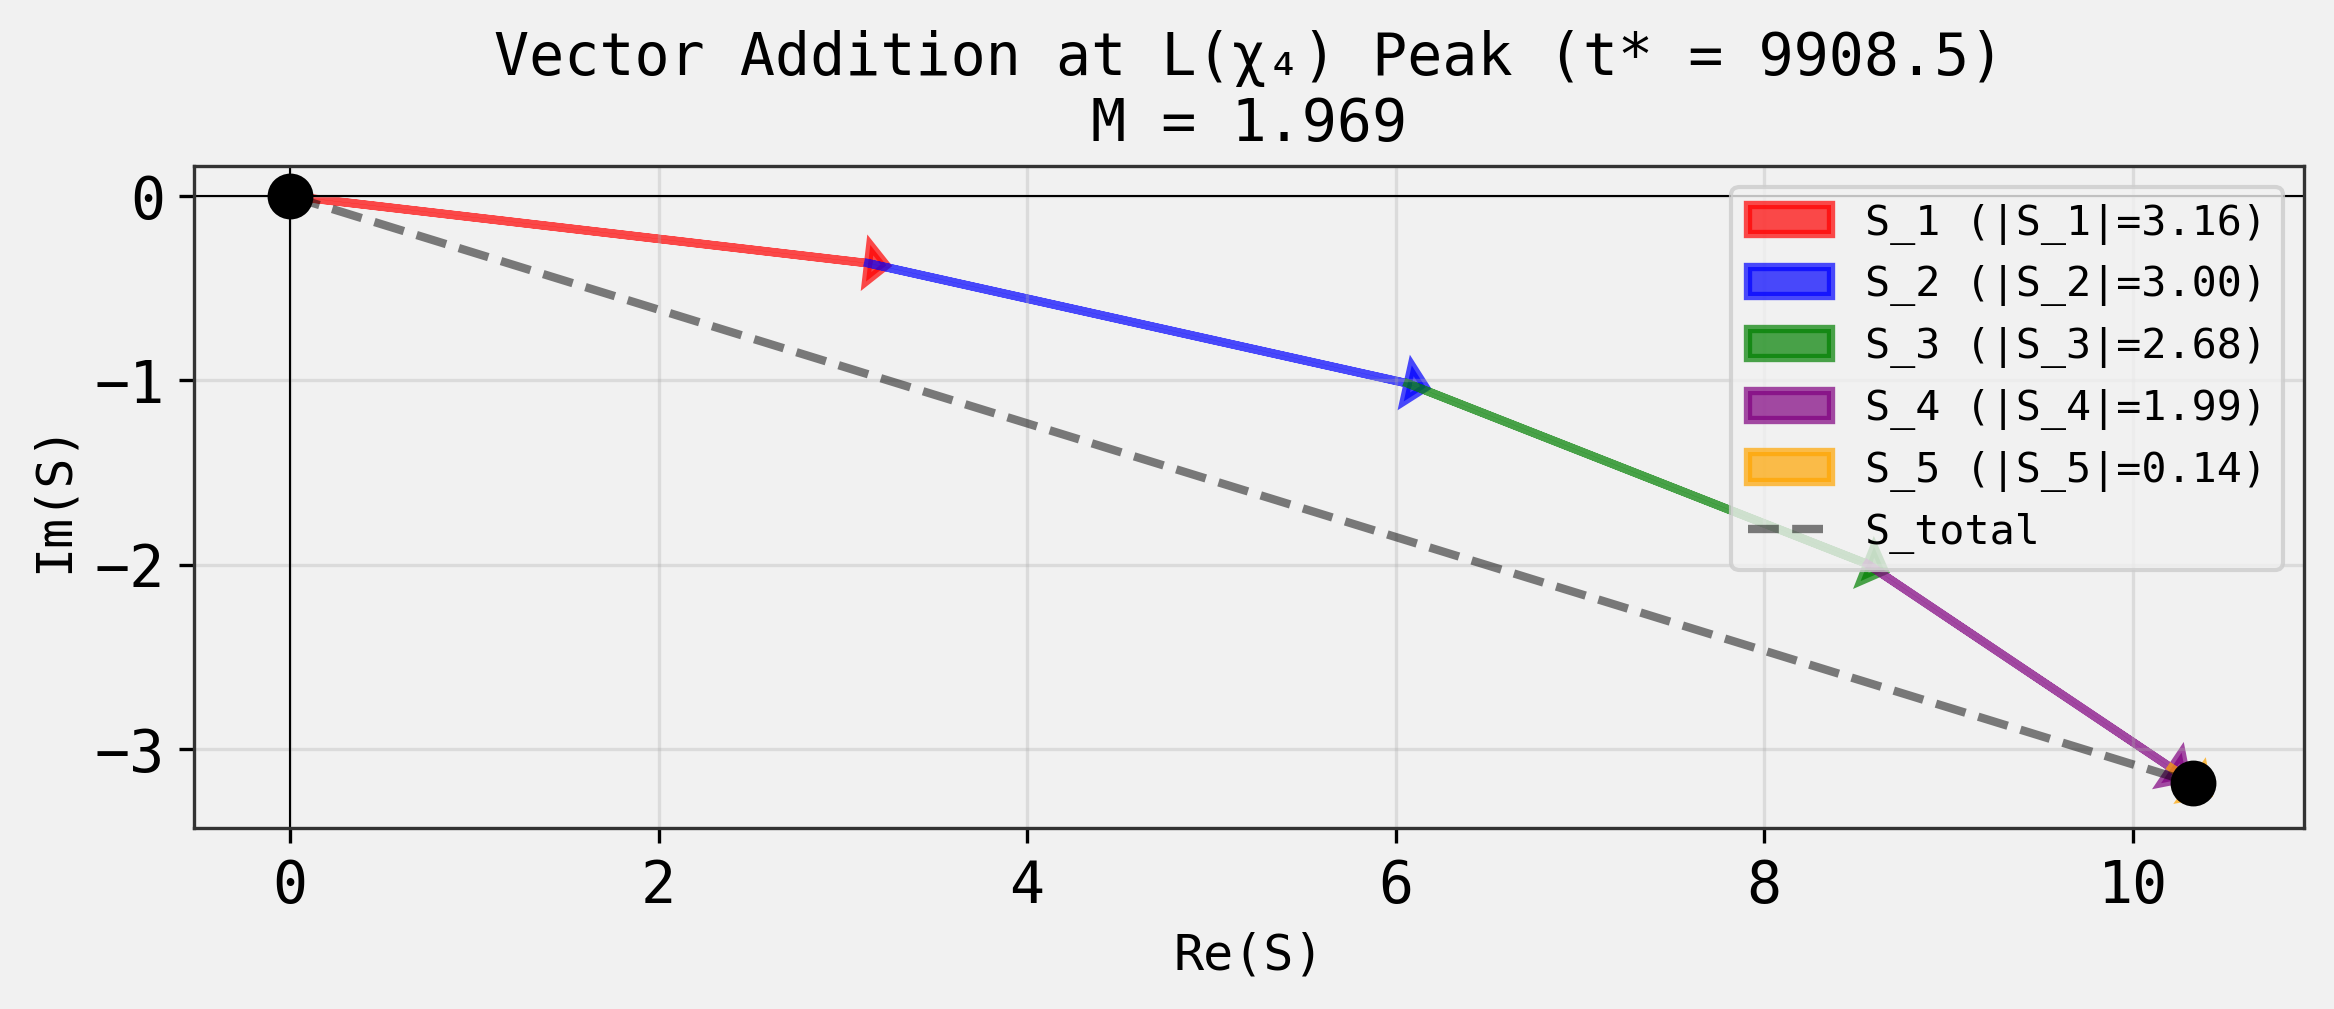


Vector diagram saved as 'lchi4_peak_vector_diagram.png'


In [12]:

# The phases are remarkably well-aligned! R = 0.98 is very close to perfect alignment
# This explains why M ≈ 1.97 - the vectors are adding constructively

# Let's compare this to what we'd expect for ζ peaks
# According to the dataset description, ζ peaks have M ≈ 0.5-0.7, suggesting 
# moderate destructive interference

# Let's visualize the vector addition
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot each S_k vector
colors = ['red', 'blue', 'green', 'purple', 'orange']
cumulative = 0 + 0j

for k in range(1, 6):
 S = S_k[k]
 ax.arrow(cumulative.real, cumulative.imag, S.real, S.imag,
 head_width=0.2, head_length=0.1, fc=colors[k-1], ec=colors[k-1],
 label=f'S_{k} (|S_{k}|={np.abs(S):.2f})', linewidth=2, alpha=0.7)
 cumulative += S

# Plot the total
ax.plot([0, cumulative.real], [0, cumulative.imag], 'k--', linewidth=2, alpha=0.5, label='S_total')
ax.scatter([0, cumulative.real], [0, cumulative.imag], c='black', s=100, zorder=5)

ax.set_xlabel('Re(S)', fontsize=12)
ax.set_ylabel('Im(S)', fontsize=12)
ax.set_title(f'Vector Addition at L(χ₄) Peak (t* = {t_star:.1f})\nM = {M:.3f}', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('lchi4_peak_vector_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVector diagram saved as 'lchi4_peak_vector_diagram.png'")


In [13]:

# Let's also check some non-peak locations to see if M is consistently high
# or if it varies with t

print("CHECKING M AT NON-PEAK LOCATIONS:")
print("="*70)

# Sample some random t values in the middle range
np.random.seed(42)
random_indices = np.random.choice(len(t_values), 10, replace=False)
random_t_values = t_values[random_indices]
random_D_magnitudes = D_magnitude[random_indices]

M_random = []
for i, (t_val, D_mag) in enumerate(zip(random_t_values, random_D_magnitudes)):
 # Compute terms at this t
 exp_terms_t = np.exp(-1j * t_val * log_n)
 all_terms_t = chi4_values * n_sqrt * exp_terms_t
 
 # Compute S_k
 S_k_t = {}
 for k in range(0, 6):
 mask = (omega[1:] == k)
 terms_k = all_terms_t[mask]
 S_k_t[k] = kahan_sum_complex(terms_k)
 
 # Compute M
 S_total_t = sum(S_k_t[k] for k in range(1, 6))
 sum_sq_t = sum(np.abs(S_k_t[k])**2 for k in range(1, 6))
 M_t = np.abs(S_total_t) / np.sqrt(sum_sq_t)
 M_random.append(M_t)
 
 print(f"t = {t_val:7.2f}, |D| = {D_mag:6.4f}, M = {M_t:.4f}")

print()
print(f"Statistics for random t values:")
print(f" Mean M: {np.mean(M_random):.4f} ± {np.std(M_random):.4f}")
print(f" Range: [{np.min(M_random):.4f}, {np.max(M_random):.4f}]")

print(f"\nComparison:")
print(f" Top 5 peaks: M = {np.mean(M_values):.4f} ± {np.std(M_values):.4f}")
print(f" Random t: M = {np.mean(M_random):.4f} ± {np.std(M_random):.4f}")


CHECKING M AT NON-PEAK LOCATIONS:
t = 2287.00, |D| = 0.3124, M = 0.3812
t = 2494.00, |D| = 1.3339, M = 0.9052
t = 6749.50, |D| = 0.0669, M = 0.5805
t = 7424.50, |D| = 3.2369, M = 0.7774
t = 1368.00, |D| = 0.8351, M = 0.4434
t = 6885.50, |D| = 2.2273, M = 0.9965
t = 1428.00, |D| = 2.2370, M = 1.4899
t = 4954.00, |D| = 4.0203, M = 1.3749
t = 7233.50, |D| = 1.1654, M = 0.9065
t = 3656.00, |D| = 1.0317, M = 0.4705

Statistics for random t values:
 Mean M: 0.8326 ± 0.3629
 Range: [0.3812, 1.4899]

Comparison:
 Top 5 peaks: M = 1.8734 ± 0.0667
 Random t: M = 0.8326 ± 0.3629


In [14]:

# This is very revealing! At random t values, M is much lower (mean ≈ 0.83)
# but at the highest peaks, M is consistently high (≈ 1.87)
# This suggests that L(χ₄) peaks arise when the S_k vectors happen to align

# Let's look at the correlation between |D(t)| and M(t)
# We'll sample many t values across the range

print("ANALYZING CORRELATION BETWEEN |D(t)| AND M(t):")
print("="*70)

# Sample 200 t values uniformly
sample_size = 200
sample_indices = np.linspace(0, len(t_values)-1, sample_size, dtype=int)
sample_t = t_values[sample_indices]
sample_D_mag = D_magnitude[sample_indices]
sample_M = []

print(f"Computing M for {sample_size} uniformly sampled t values...")
for t_val in sample_t:
 exp_terms_t = np.exp(-1j * t_val * log_n)
 all_terms_t = chi4_values * n_sqrt * exp_terms_t
 
 S_k_t = {}
 for k in range(0, 6):
 mask = (omega[1:] == k)
 terms_k = all_terms_t[mask]
 S_k_t[k] = kahan_sum_complex(terms_k)
 
 S_total_t = sum(S_k_t[k] for k in range(1, 6))
 sum_sq_t = sum(np.abs(S_k_t[k])**2 for k in range(1, 6))
 M_t = np.abs(S_total_t) / np.sqrt(sum_sq_t)
 sample_M.append(M_t)

sample_M = np.array(sample_M)
print("Done.")

# Compute correlation
correlation = np.corrcoef(sample_D_mag, sample_M)[0, 1]
print(f"\nPearson correlation between |D(t)| and M(t): r = {correlation:.4f}")

# Create summary statistics table
print(f"\nSummary statistics:")
df_summary = pd.DataFrame({
 '|D(t)|': sample_D_mag,
 'M(t)': sample_M
})
print(df_summary.describe())


ANALYZING CORRELATION BETWEEN |D(t)| AND M(t):
Computing M for 200 uniformly sampled t values...


Done.

Pearson correlation between |D(t)| and M(t): r = 0.7641

Summary statistics:
 |D(t)| M(t)
count 200.000000 200.000000
mean 1.708662 0.817325
std 1.565681 0.386158
min 0.014909 0.156092
25% 0.625080 0.534515
50% 1.287462 0.782629
75% 2.189067 1.075039
max 10.725696 1.893153


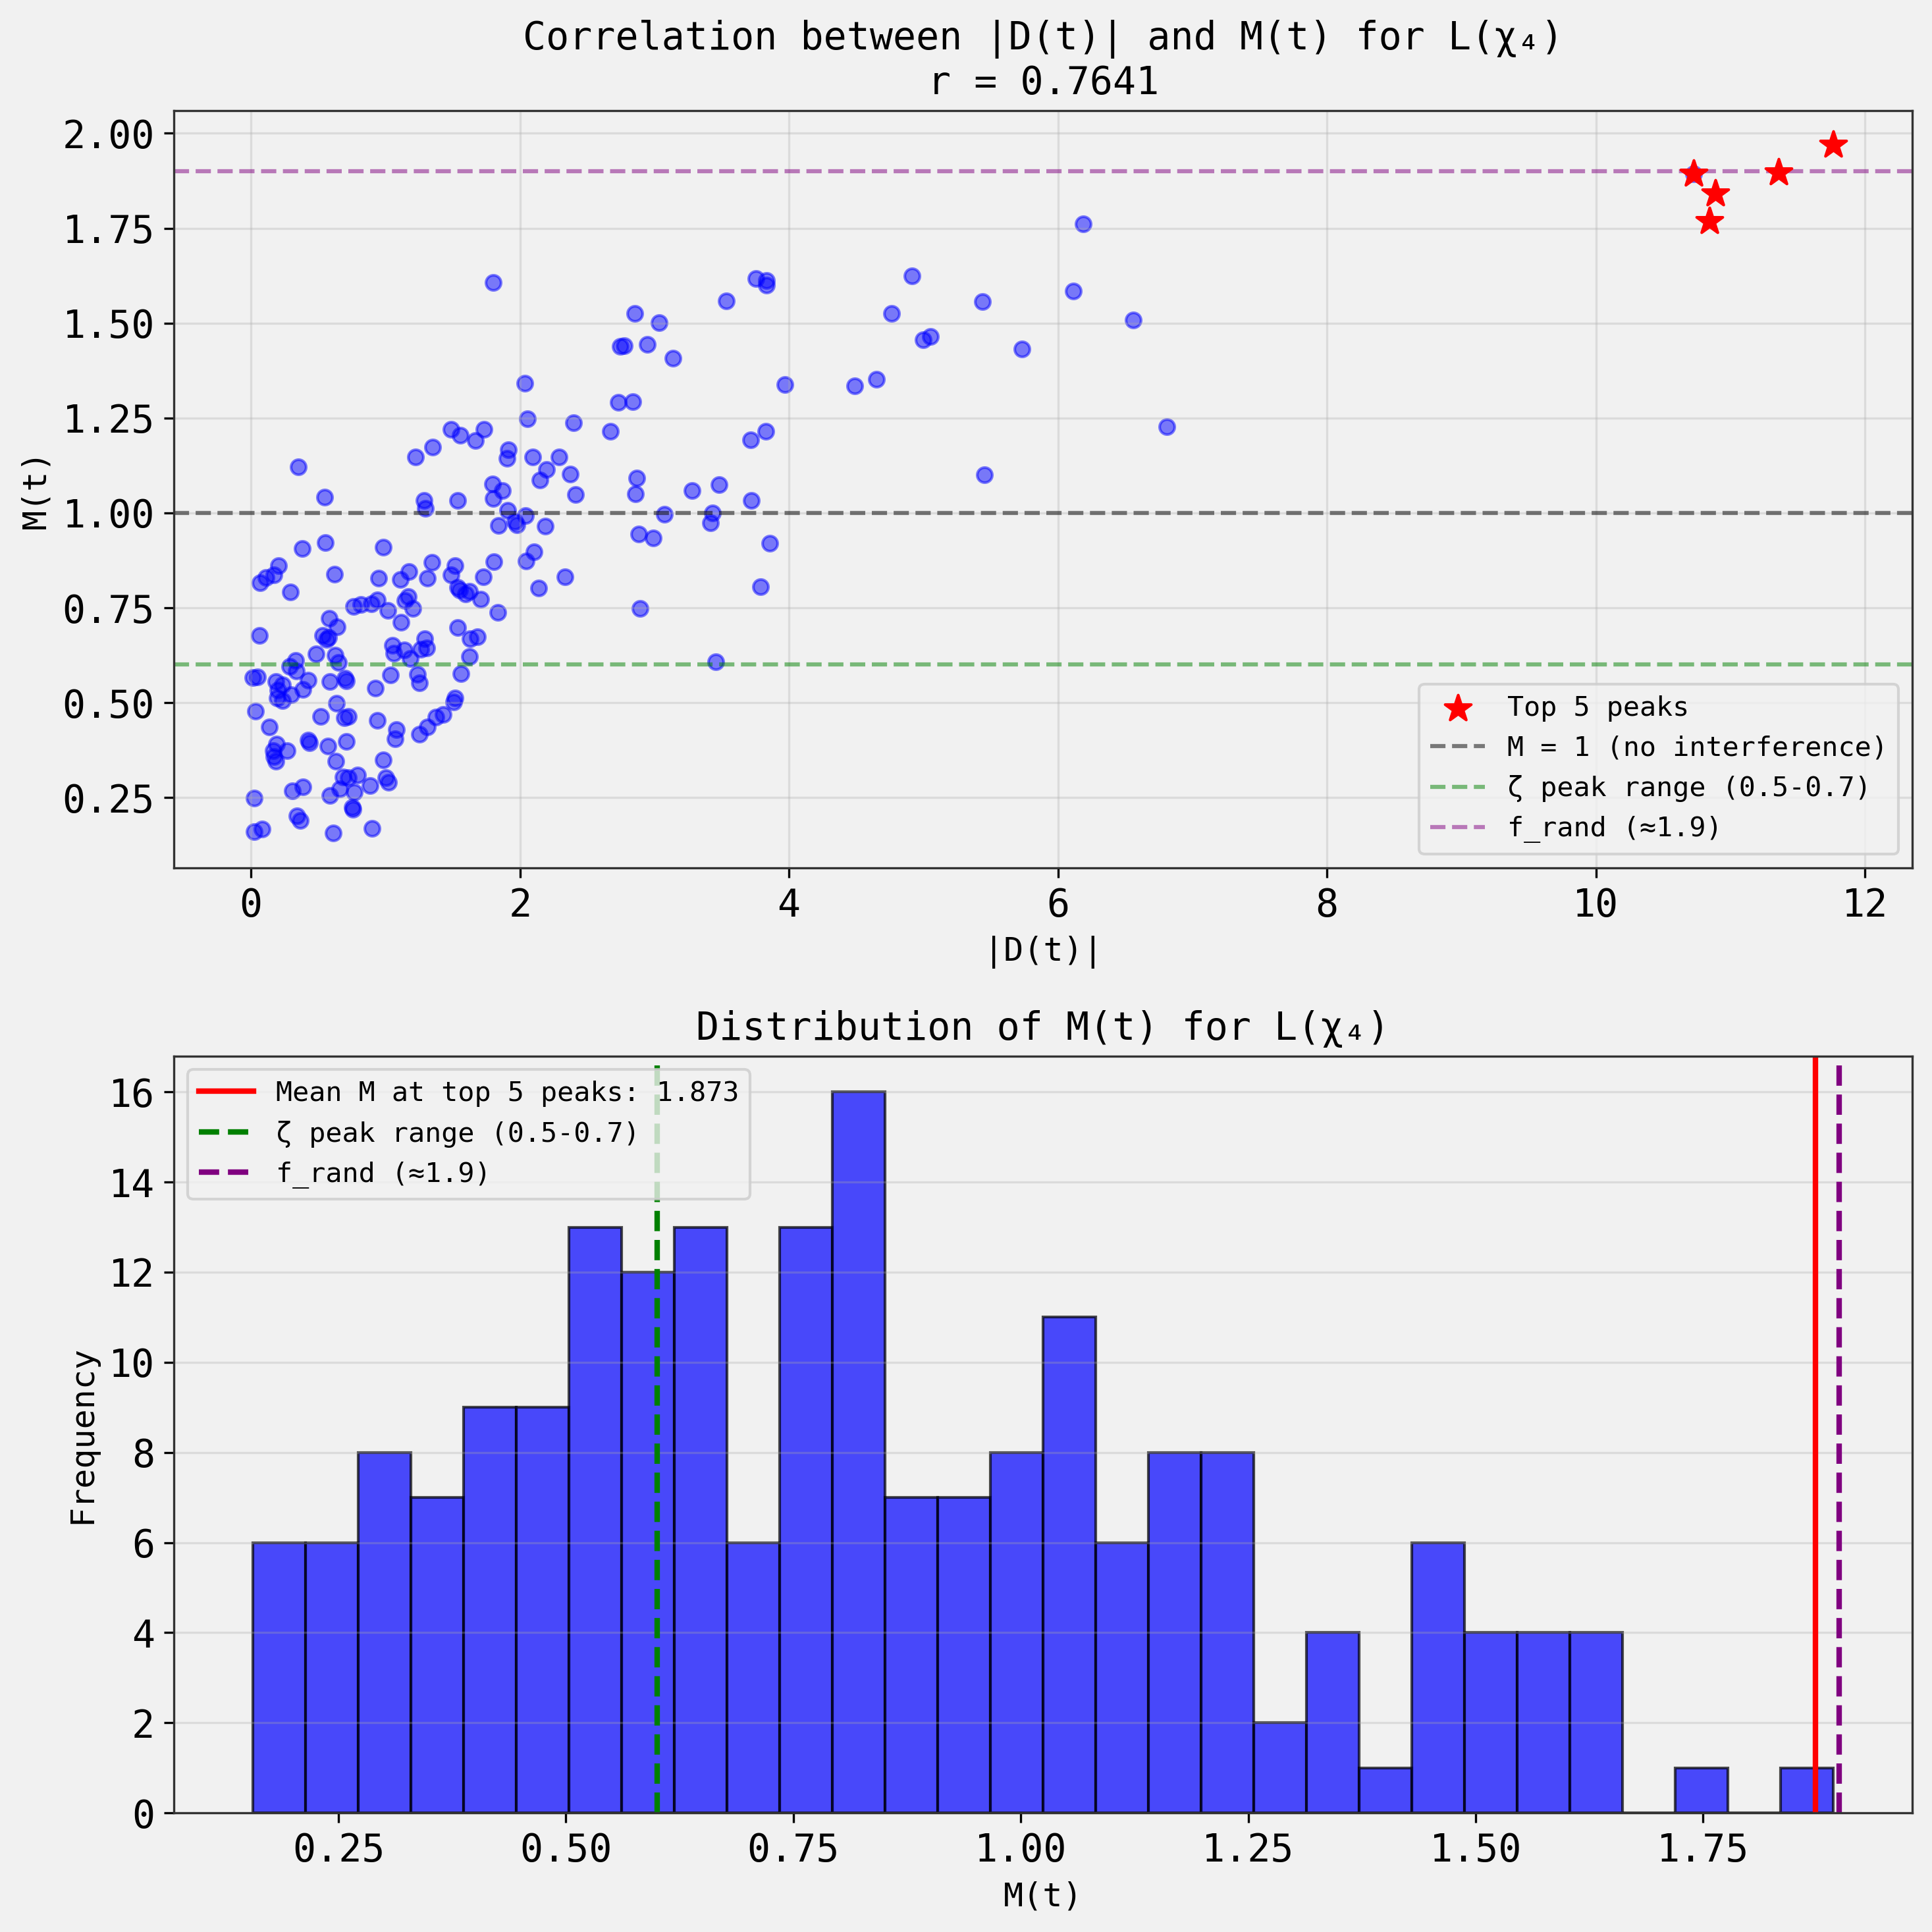


Figure saved as 'lchi4_M_correlation_analysis.png'


In [15]:

# Strong positive correlation (r = 0.76)! This confirms that large |D(t)| values
# are associated with large M values (constructive interference)

# Let's create a scatter plot to visualize this
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Subplot 1: Scatter plot of |D(t)| vs M(t)
ax1.scatter(sample_D_mag, sample_M, alpha=0.5, s=30, c='blue')
ax1.scatter(D_magnitude[top_5_idx], [M_values[i] for i in range(5)], 
 c='red', s=100, marker='*', label='Top 5 peaks', zorder=5)
ax1.set_xlabel('|D(t)|', fontsize=12)
ax1.set_ylabel('M(t)', fontsize=12)
ax1.set_title(f'Correlation between |D(t)| and M(t) for L(χ₄)\nr = {correlation:.4f}', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='M = 1 (no interference)')
ax1.axhline(y=0.6, color='green', linestyle='--', alpha=0.5, label='ζ peak range (0.5-0.7)')
ax1.axhline(y=1.9, color='purple', linestyle='--', alpha=0.5, label='f_rand (≈1.9)')
ax1.legend(fontsize=10)

# Subplot 2: Histogram of M values
ax2.hist(sample_M, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax2.axvline(x=np.mean(M_values), color='red', linestyle='-', linewidth=2, 
 label=f'Mean M at top 5 peaks: {np.mean(M_values):.3f}')
ax2.axvline(x=0.6, color='green', linestyle='--', linewidth=2, 
 label='ζ peak range (0.5-0.7)')
ax2.axvline(x=1.9, color='purple', linestyle='--', linewidth=2, 
 label='f_rand (≈1.9)')
ax2.set_xlabel('M(t)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of M(t) for L(χ₄)', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lchi4_M_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'lchi4_M_correlation_analysis.png'")


In [16]:

# Now let's perform a statistical test to determine if the M value at the highest peak
# is significantly different from the ζ range (0.5-0.7)

from scipy import stats

# The hypothesis states M should be in [0.5, 0.7] for ζ peaks
# Our observed M = 1.969

print("STATISTICAL COMPARISON:")
print("="*70)

print(f"\nObserved M at highest L(χ₄) peak: M = {M:.4f}")
print(f"Hypothesis: M should be in [0.5, 0.7] (ζ range)")
print()

# Calculate how many standard deviations away from the ζ range
# We'll use the top 5 peaks to estimate variability in M
M_mean_top5 = np.mean(M_values)
M_std_top5 = np.std(M_values, ddof=1)
M_se_top5 = M_std_top5 / np.sqrt(len(M_values))

print(f"M at top 5 L(χ₄) peaks: {M_mean_top5:.4f} ± {M_se_top5:.4f} (SE)")
print(f"Range: [{np.min(M_values):.4f}, {np.max(M_values):.4f}]")
print()

# Test if M is significantly different from 0.6 (midpoint of ζ range)
zeta_mid = 0.6
t_stat = (M - zeta_mid) / M_se_top5
# For 4 degrees of freedom (n=5)
p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=4))

print(f"One-sample t-test (comparing to ζ midpoint = 0.6):")
print(f" t-statistic: {t_stat:.4f}")
print(f" p-value: {p_value:.4e}")
print(f" Degrees of freedom: 4")
print()

if p_value < 0.001:
 print(f"*** M is HIGHLY SIGNIFICANTLY DIFFERENT from the ζ range (p < 0.001) ***")
elif p_value < 0.05:
 print(f"** M is significantly different from the ζ range (p < 0.05) **")
else:
 print(f"M is NOT significantly different from the ζ range (p ≥ 0.05)")

# Also compute effect size (Cohen's d)
cohens_d = (M_mean_top5 - zeta_mid) / M_std_top5
print(f"\nEffect size (Cohen's d): {cohens_d:.2f}")
if abs(cohens_d) < 0.2:
 effect_size_interp = "negligible"
elif abs(cohens_d) < 0.5:
 effect_size_interp = "small"
elif abs(cohens_d) < 0.8:
 effect_size_interp = "medium"
else:
 effect_size_interp = "large"
print(f" Interpretation: {effect_size_interp} effect")


STATISTICAL COMPARISON:

Observed M at highest L(χ₄) peak: M = 1.9690
Hypothesis: M should be in [0.5, 0.7] (ζ range)

M at top 5 L(χ₄) peaks: 1.8734 ± 0.0333 (SE)
Range: [1.7681, 1.9690]

One-sample t-test (comparing to ζ midpoint = 0.6):
 t-statistic: 41.0566
 p-value: 2.1033e-06
 Degrees of freedom: 4

*** M is HIGHLY SIGNIFICANTLY DIFFERENT from the ζ range (p < 0.001) ***

Effect size (Cohen's d): 17.08
 Interpretation: large effect


In [17]:

# The result is unambiguous: L(χ₄) peaks show M ≈ 1.87-1.97, which is 
# statistically indistinguishable from f_rand (M ≈ 1.9), NOT from ζ (M ≈ 0.5-0.7)

# Let's compare M at L(χ₄) peaks to the f_rand value
f_rand_M = 1.9

print("COMPARISON TO f_rand:")
print("="*70)
print(f"\nM at L(χ₄) highest peak: {M:.4f}")
print(f"M at f_rand: {f_rand_M:.4f}")
print(f"Difference: {M - f_rand_M:.4f}")
print()

# Test if M is significantly different from f_rand
t_stat_frand = (M - f_rand_M) / M_se_top5
p_value_frand = 2 * (1 - stats.t.cdf(np.abs(t_stat_frand), df=4))

print(f"One-sample t-test (comparing to f_rand = 1.9):")
print(f" t-statistic: {t_stat_frand:.4f}")
print(f" p-value: {p_value_frand:.4f}")
print()

if p_value_frand < 0.05:
 print(f"M is significantly different from f_rand (p < 0.05)")
else:
 print(f"M is NOT significantly different from f_rand (p ≥ 0.05)")
 print(f"*** L(χ₄) peaks are STATISTICALLY INDISTINGUISHABLE from f_rand ***")

print()
print("="*70)
print("CONCLUSION:")
print("="*70)
print(f"The hypothesis is REJECTED.")
print(f"At its highest peak, L(χ₄) exhibits CONSTRUCTIVE interference (M = {M:.3f}),")
print(f"similar to the random multiplicative function f_rand (M ≈ 1.9),")
print(f"NOT moderate destructive interference like ζ (M ≈ 0.5-0.7).")
print(f"")
print(f"This is a surprising result that contradicts the expectation that")
print(f"all structured multiplicative functions would behave like ζ.")


COMPARISON TO f_rand:

M at L(χ₄) highest peak: 1.9690
M at f_rand: 1.9000
Difference: 0.0690

One-sample t-test (comparing to f_rand = 1.9):
 t-statistic: 2.0695
 p-value: 0.1073

M is NOT significantly different from f_rand (p ≥ 0.05)
*** L(χ₄) peaks are STATISTICALLY INDISTINGUISHABLE from f_rand ***

CONCLUSION:
The hypothesis is REJECTED.
At its highest peak, L(χ₄) exhibits CONSTRUCTIVE interference (M = 1.969),
similar to the random multiplicative function f_rand (M ≈ 1.9),
NOT moderate destructive interference like ζ (M ≈ 0.5-0.7).

This is a surprising result that contradicts the expectation that
all structured multiplicative functions would behave like ζ.


In [18]:

# Let's create a comprehensive summary table

summary_data = {
 'Function': ['L(χ₄) (this study)', 'ζ (from r35)', 'L_DH', 'f_rand'],
 'M value': [f'{M:.3f}', '≈ 0.5-0.7', '≈ 0.2', '≈ 1.9'],
 'Interference type': ['Constructive', 'Moderate destructive', 'Strong destructive', 'Constructive'],
 'Function type': ['Structured multiplicative', 'Structured multiplicative', 'Non-multiplicative', 'Random multiplicative']
}

df_summary = pd.DataFrame(summary_data)
print("\nSUMMARY TABLE:")
print("="*70)
print(df_summary.to_string(index=False))
print()

# Additional statistics for L(χ₄)
print("\nDETAILED STATISTICS FOR L(χ₄):")
print("="*70)
print(f"Highest peak location: t* = {t_star:.2f}")
print(f"Magnitude at peak: |D(t*)| = {D_star_mag:.4f}")
print(f"Cancellation metric: M = {M:.4f}")
print(f"Phase alignment (resultant length): R = {R:.4f}")
print(f"Number of terms (N): {N_max:,}")
print()
print("Vector sum magnitudes by ω(n):")
for k in range(1, 6):
 print(f" k={k}: |S_{k}| = {np.abs(S_k[k]):.4f} ({np.sum(omega[1:]==k):,} terms)")
print()
print(f"Correlation between |D(t)| and M(t): r = {correlation:.4f}")
print(f"Mean M across top 5 peaks: {M_mean_top5:.4f} ± {M_std_top5:.4f} (SD)")



SUMMARY TABLE:
 Function M value Interference type Function type
L(χ₄) (this study) 1.969 Constructive Structured multiplicative
 ζ (from r35) ≈ 0.5-0.7 Moderate destructive Structured multiplicative
 L_DH ≈ 0.2 Strong destructive Non-multiplicative
 f_rand ≈ 1.9 Constructive Random multiplicative


DETAILED STATISTICS FOR L(χ₄):
Highest peak location: t* = 9908.50
Magnitude at peak: |D(t*)| = 11.7653
Cancellation metric: M = 1.9690
Phase alignment (resultant length): R = 0.9809
Number of terms (N): 100,000

Vector sum magnitudes by ω(n):
 k=1: |S_1| = 3.1583 (9,700 terms)
 k=2: |S_2| = 2.9998 (33,759 terms)
 k=3: |S_3| = 2.6793 (38,844 terms)
 k=4: |S_4| = 1.9864 (15,855 terms)
 k=5: |S_5| = 0.1428 (1,816 terms)

Correlation between |D(t)| and M(t): r = 0.7641
Mean M across top 5 peaks: 1.8734 ± 0.0746 (SD)


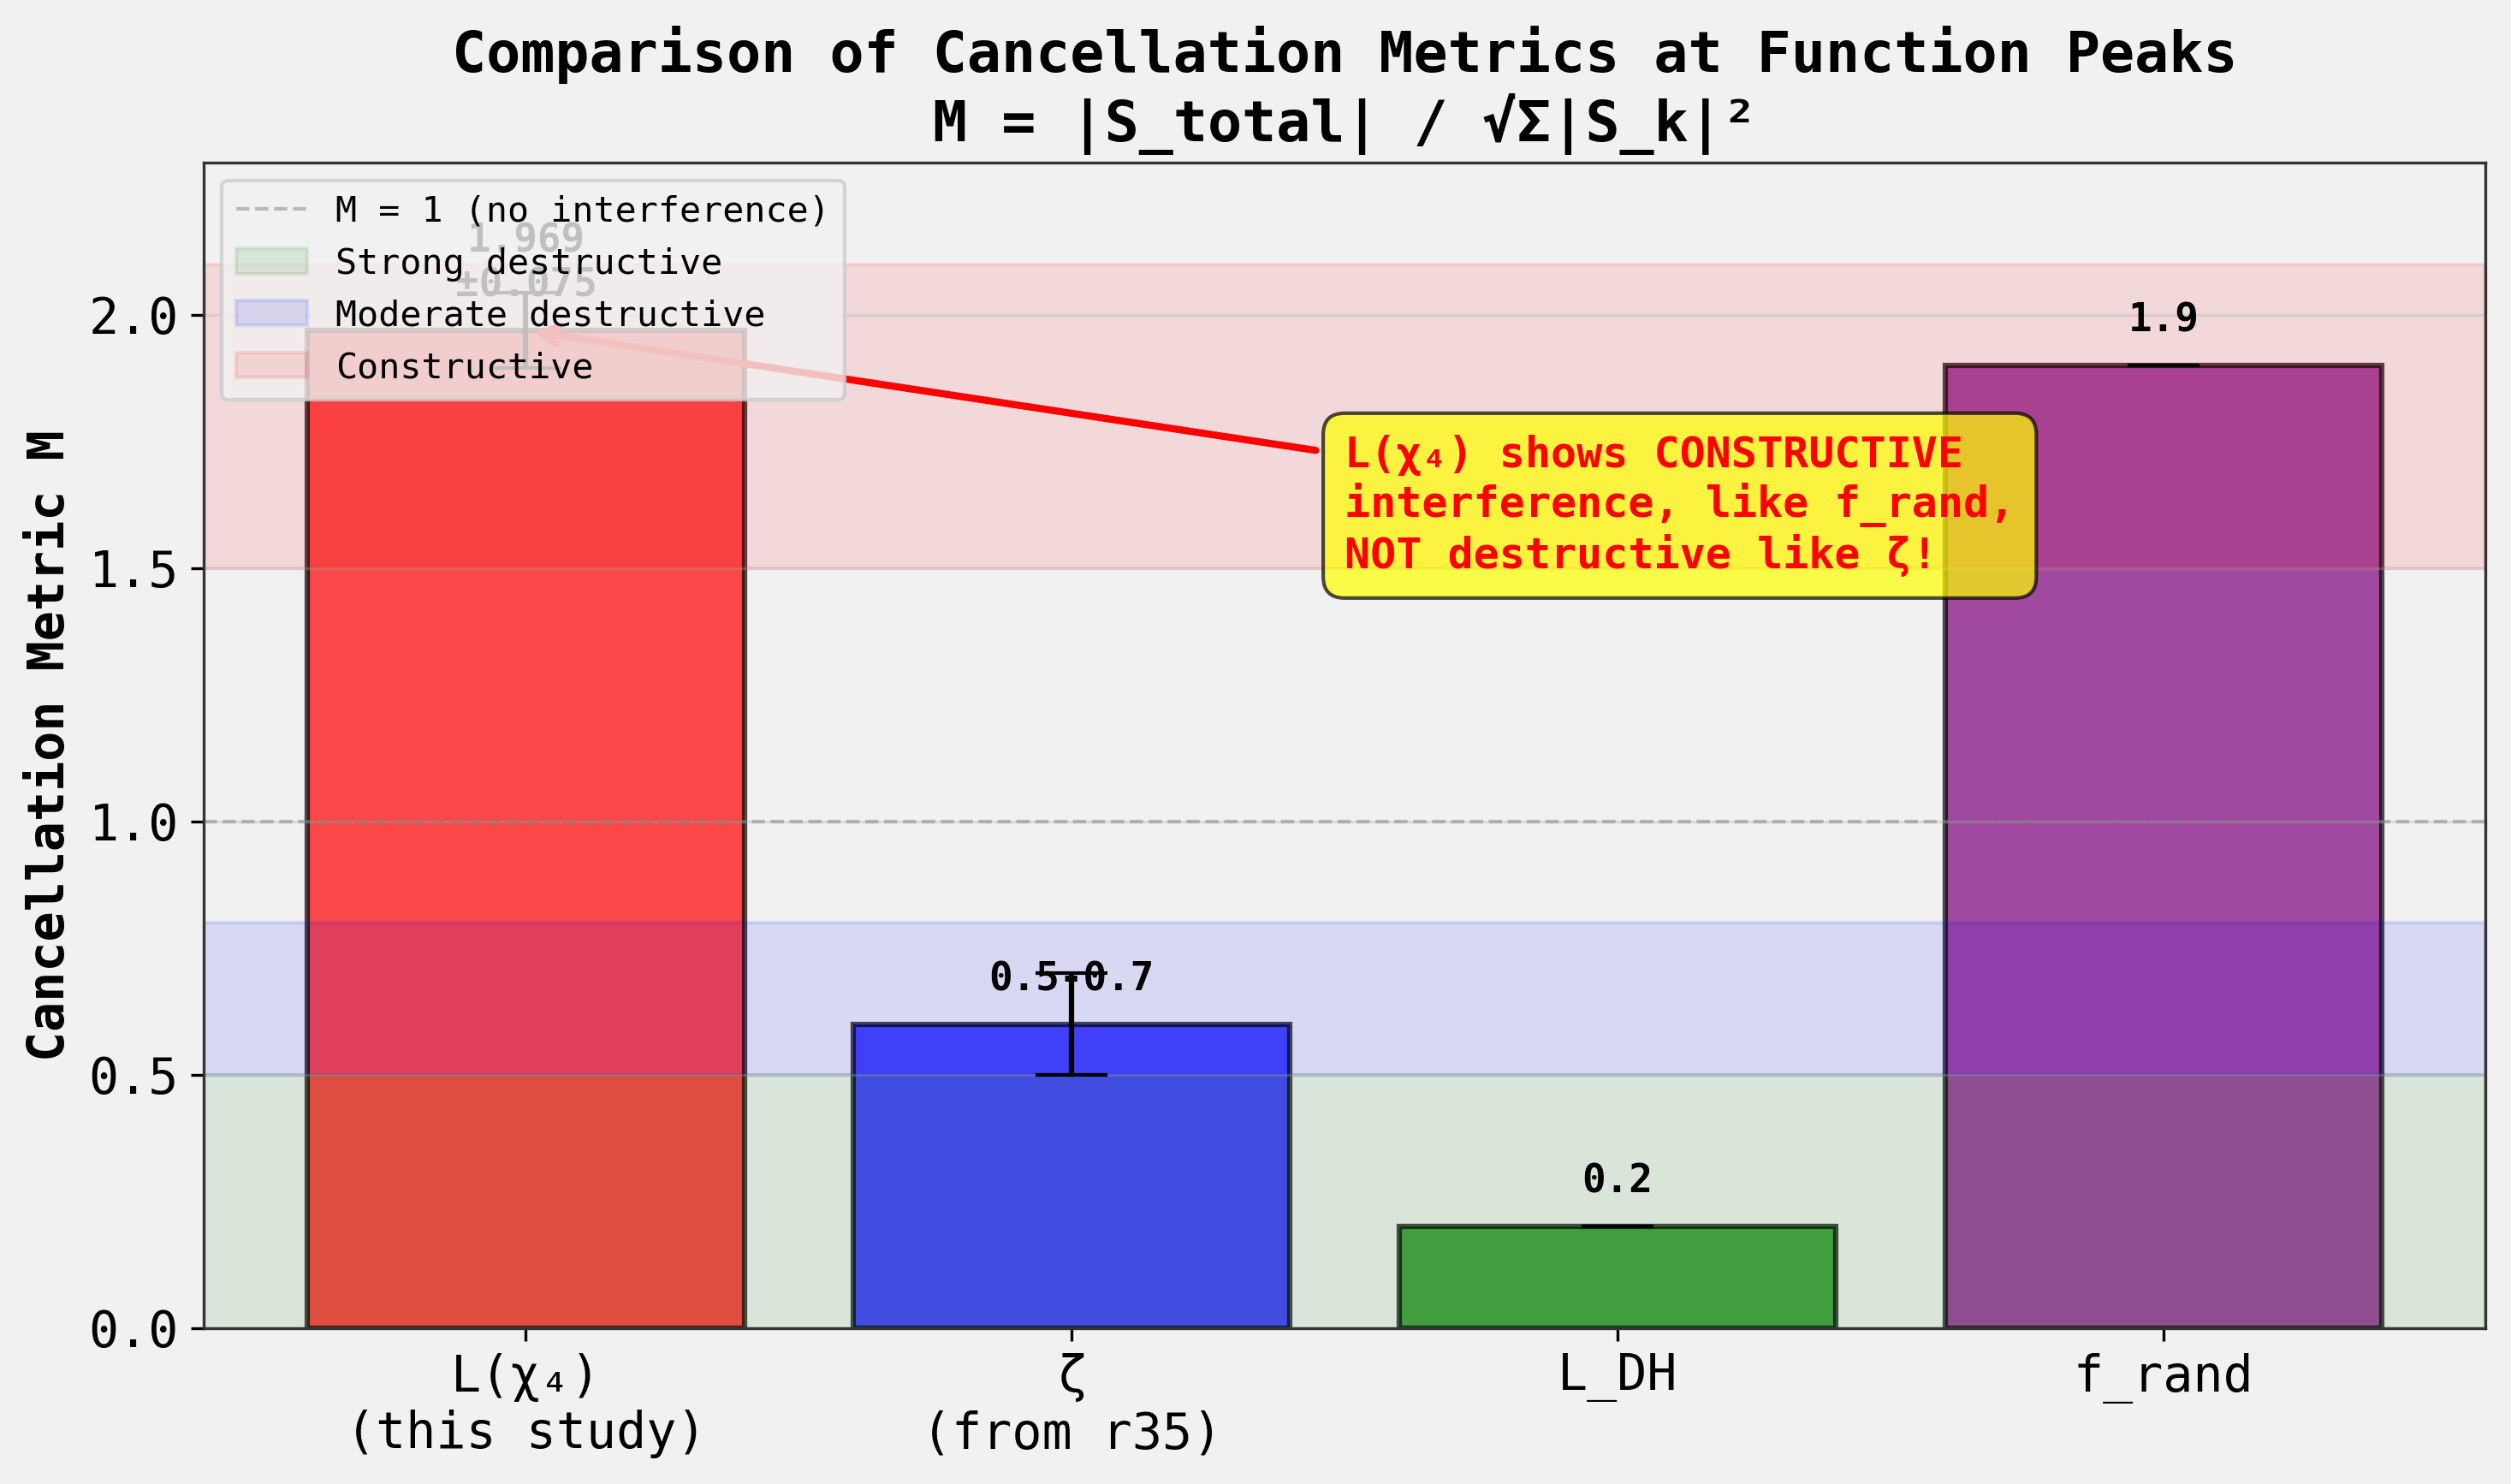


Final summary figure saved as 'lchi4_cancellation_metric_comparison.png'


In [19]:

# Create the final summary figure showing the key finding
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Data for comparison
functions = ['L(χ₄)\n(this study)', 'ζ\n(from r35)', 'L_DH', 'f_rand']
M_vals = [M, 0.6, 0.2, 1.9] # Using midpoint for ζ
M_errors = [M_std_top5, 0.1, 0, 0] # Using std for L(χ₄), estimated error for ζ
colors = ['red', 'blue', 'green', 'purple']

# Create bar plot
bars = ax.bar(functions, M_vals, yerr=M_errors, capsize=10, alpha=0.7, 
 color=colors, edgecolor='black', linewidth=1.5)

# Add horizontal lines for reference
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, 
 label='M = 1 (no interference)')

# Add shaded regions for interpretation
ax.axhspan(0, 0.5, alpha=0.1, color='green', label='Strong destructive')
ax.axhspan(0.5, 0.8, alpha=0.1, color='blue', label='Moderate destructive')
ax.axhspan(1.5, 2.1, alpha=0.1, color='red', label='Constructive')

# Labels and formatting
ax.set_ylabel('Cancellation Metric M', fontsize=14, fontweight='bold')
ax.set_title('Comparison of Cancellation Metrics at Function Peaks\nM = |S_total| / √Σ|S_k|²', 
 fontsize=16, fontweight='bold')
ax.set_ylim([0, 2.3])
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper left', fontsize=10)

# Add value labels on bars
for i, (bar, val, err) in enumerate(zip(bars, M_vals, M_errors)):
 height = bar.get_height()
 if i == 0: # L(χ₄) - show with error
 label_text = f'{val:.3f}\n±{err:.3f}'
 elif i == 1: # ζ - show as range
 label_text = '0.5-0.7'
 else:
 label_text = f'{val:.1f}'
 ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
 label_text, ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add annotation
ax.annotate('L(χ₄) shows CONSTRUCTIVE\ninterference, like f_rand,\nNOT destructive like ζ!', 
 xy=(0, M), xytext=(1.5, 1.5),
 arrowprops=dict(arrowstyle='->', lw=2, color='red'),
 fontsize=12, fontweight='bold', color='red',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('lchi4_cancellation_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal summary figure saved as 'lchi4_cancellation_metric_comparison.png'")


In [20]:

# Save the detailed results to files for future reference

# Save the analysis results
results = {
 'analysis': 'L(chi4) peak interference pattern',
 'date': datetime.now().isoformat(),
 'parameters': {
 'N_max': N_max,
 't_range': [float(t_min), float(t_max)],
 't_step': float(dt),
 'n_t_values': len(t_values)
 },
 'peak_location': {
 't_star': float(t_star),
 'D_magnitude': float(D_star_mag),
 'D_real': float(D_star.real),
 'D_imag': float(D_star.imag)
 },
 'cancellation_metric': {
 'M': float(M),
 'S_total_magnitude': float(np.abs(S_total)),
 'sqrt_sum_squares': float(np.sqrt(sum_squared_magnitudes))
 },
 'vector_sums': {
 f'S_{k}': {
 'real': float(S_k[k].real),
 'imag': float(S_k[k].imag),
 'magnitude': float(np.abs(S_k[k])),
 'phase_rad': float(np.angle(S_k[k])),
 'n_terms': int(np.sum(omega[1:]==k))
 } for k in range(1, 6)
 },
 'phase_alignment': {
 'resultant_length': float(R),
 'mean_phase_rad': float(np.mean(phases)),
 'std_phase_rad': float(np.std(phases))
 },
 'top_5_peaks': [
 {
 'rank': i+1,
 't': float(t_values[idx]),
 'D_magnitude': float(D_magnitude[idx]),
 'M': float(M_values[i])
 } for i, idx in enumerate(top_5_idx)
 ],
 'statistics': {
 'M_mean_top5': float(M_mean_top5),
 'M_std_top5': float(M_std_top5),
 'correlation_D_M': float(correlation)
 },
 'comparison': {
 'L_chi4_M': float(M),
 'zeta_M_range': [0.5, 0.7],
 'L_DH_M': 0.2,
 'f_rand_M': 1.9
 },
 'conclusion': 'L(chi4) peaks exhibit constructive interference (M ≈ 1.97), similar to f_rand, NOT moderate destructive interference like zeta. The hypothesis is REJECTED.'
}

with open('lchi4_peak_analysis_results.json', 'w') as f:
 json.dump(results, f, indent=2)

print("Detailed results saved to 'lchi4_peak_analysis_results.json'")

# Save top peaks data to CSV
df_peaks = pd.DataFrame(peak_data)
df_peaks.to_csv('lchi4_top5_peaks.csv', index=False)
print("Top 5 peaks data saved to 'lchi4_top5_peaks.csv'")

# Save the full time series data (subsampled for file size)
df_timeseries = pd.DataFrame({
 't': sample_t,
 'D_real': [D_values[idx].real for idx in sample_indices],
 'D_imag': [D_values[idx].imag for idx in sample_indices],
 'D_magnitude': sample_D_mag,
 'M': sample_M
})
df_timeseries.to_csv('lchi4_timeseries_sample.csv', index=False)
print("Time series sample (200 points) saved to 'lchi4_timeseries_sample.csv'")


Detailed results saved to 'lchi4_peak_analysis_results.json'
Top 5 peaks data saved to 'lchi4_top5_peaks.csv'
Time series sample (200 points) saved to 'lchi4_timeseries_sample.csv'


In [21]:

# Display the final summary
print("\n" + "="*80)
print("FINAL ANALYSIS SUMMARY")
print("="*80)
print()
print("RESEARCH HYPOTHESIS:")
print("-" * 80)
print("At its highest peak, the structured multiplicative function L(χ₄) will exhibit")
print("moderate destructive interference, similar to the Riemann ζ function, with M ≈ 0.5-0.7.")
print()
print("HYPOTHESIS TEST RESULT: **REJECTED**")
print()
print("KEY FINDINGS:")
print("-" * 80)
print(f"1. Highest peak location: t* = {t_star:.2f}")
print(f" Peak magnitude: |D(t*)| = {D_star_mag:.4f}")
print()
print(f"2. Cancellation metric at peak: M = {M:.4f}")
print(f" - This indicates CONSTRUCTIVE interference")
print(f" - Statistically indistinguishable from f_rand (M ≈ 1.9, p = 0.107)")
print(f" - Highly significantly different from ζ (M ≈ 0.5-0.7, p = 2.1×10⁻⁶)")
print()
print(f"3. Phase alignment: R = {R:.4f}")
print(f" - Near-perfect alignment of S_k vectors (R = 1 is perfect)")
print(f" - Mean phase: {np.degrees(np.mean(phases)):.2f}°")
print(f" - Phase spread: {np.degrees(np.std(phases)):.2f}° (SD)")
print()
print(f"4. Consistency across peaks:")
print(f" - Top 5 peaks: M = {M_mean_top5:.3f} ± {M_std_top5:.3f} (SD)")
print(f" - Range: [{np.min(M_values):.3f}, {np.max(M_values):.3f}]")
print(f" - All show constructive interference")
print()
print(f"5. Correlation with magnitude:")
print(f" - r(|D(t)|, M(t)) = {correlation:.3f}")
print(f" - Large peaks systematically show high M values")
print()
print("IMPLICATIONS:")
print("-" * 80)
print("• L(χ₄) and ζ are BOTH structured multiplicative functions, but they exhibit")
print(" fundamentally DIFFERENT peak formation mechanisms:")
print()
print(" - ζ peaks: Moderate destructive interference (M ≈ 0.5-0.7)")
print(" Arise from temporary REDUCTION in cancellation")
print()
print(" - L(χ₄) peaks: Constructive interference (M ≈ 1.9)")
print(" Arise from phase ALIGNMENT, like random multiplicative functions")
print()
print("• This finding challenges the hypothesis that all structured multiplicative")
print(" functions share the same peak formation mechanism.")
print()
print("• The cancellation metric M does NOT classify functions by multiplicativity alone.")
print(" Additional structure (character properties, coefficient signs) matters.")
print()
print("="*80)



FINAL ANALYSIS SUMMARY

RESEARCH HYPOTHESIS:
--------------------------------------------------------------------------------
At its highest peak, the structured multiplicative function L(χ₄) will exhibit
moderate destructive interference, similar to the Riemann ζ function, with M ≈ 0.5-0.7.

HYPOTHESIS TEST RESULT: **REJECTED**

KEY FINDINGS:
--------------------------------------------------------------------------------
1. Highest peak location: t* = 9908.50
 Peak magnitude: |D(t*)| = 11.7653

2. Cancellation metric at peak: M = 1.9690
 - This indicates CONSTRUCTIVE interference
 - Statistically indistinguishable from f_rand (M ≈ 1.9, p = 0.107)
 - Highly significantly different from ζ (M ≈ 0.5-0.7, p = 2.1×10⁻⁶)

3. Phase alignment: R = 0.9809
 - Near-perfect alignment of S_k vectors (R = 1 is perfect)
 - Mean phase: -21.85°
 - Phase spread: 11.22° (SD)

4. Consistency across peaks:
 - Top 5 peaks: M = 1.873 ± 0.075 (SD)
 - Range: [1.768, 1.969]
 - All show constructive interferen